# 🛢️ Oil Reserve Prediction and Investment Risk Analysis
### Executive Summary
This analysis evaluates three oil regions to determine where OilyGiant should invest $100 million in developing 200 new wells. After training linear regression models, calculating profits, and running a 1,000‑iteration bootstrapping risk assessment, Region 1 emerges as the only region that meets the company’s strict 2.5% maximum risk‑of‑loss threshold. With a loss risk of just 1.5% and highly stable predictions, Region 1 is the safest and most financially responsible choice for development.

### Project Overview
OilyGiant is preparing to make a major capital investment: drilling 200 new oil wells at a total cost of $100 million. To make an informed decision, the company needs reliable predictions about which region can deliver profitable returns while staying within the required risk tolerance.

Using geological data from three regions, I built linear regression models to estimate oil reserves and evaluated each region’s financial viability through profit calculations and risk analysis.

### Methodology
This project follows a structured, five‑step approach:

- Data Exploration – Inspect and validate the datasets for all three regions.

- Model Training – Build linear regression models to predict oil reserves.

- Profit Estimation – Select the top 200 predicted wells and calculate expected profit.

- Risk Analysis – Use bootstrapping to estimate uncertainty and loss probability.

- Final Recommendation – Determine whether any region meets the company’s investment criteria.

### Why This Matters
A $100 million investment demands a high level of confidence. Even small prediction errors can translate into millions of dollars gained or lost. This is why OilyGiant enforces a strict 2.5% maximum acceptable risk of loss — any region exceeding this threshold is automatically disqualified, regardless of potential profit.

### Business Constraints
Budget: $100 million

Wells to develop: 200

Revenue: $4,500 per thousand barrels

Risk tolerance: Loss probability must be below 2.5%

Model requirement: Linear regression only

### Goal
Identify whether any region meets both profitability and risk requirements and provide a clear, data‑driven recommendation for OilyGiant’s next steps.




In [1]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np
from numpy.random import RandomState
import matplotlib.pyplot as plt

### Load and Inspect

I'm loading the dataset for Region 0, 1, and 2 and previewing the first 10 rows to understand the structure. Each row represents a well, with three geological features (f0, f1, f2) and the target variable (product = oil reserves).


### geo_data_0.csv exploration

In [2]:
data0 = pd.read_csv('geo_data_0.csv')
print(data0.head(10))

      id        f0        f1        f2     product
0  txEyH  0.705745 -0.497823  1.221170  105.280062
1  2acmU  1.334711 -0.340164  4.365080   73.037750
2  409Wp  1.022732  0.151990  1.419926   85.265647
3  iJLyR -0.032172  0.139033  2.978566  168.620776
4  Xdl7t  1.988431  0.155413  4.751769  154.036647
5  wX4Hy  0.969570  0.489775 -0.735383   64.741541
6  tL6pL  0.645075  0.530656  1.780266   49.055285
7  BYPU6 -0.400648  0.808337 -5.624670   72.943292
8  j9Oui  0.643105 -0.551583  2.372141  113.356160
9  OLuZU  2.173381  0.563698  9.441852  127.910945


### Check for Missing Values and Duplicates

I’m verifying the dataset size, checking for missing values, and inspecting the uniqueness of well IDs. Although there are 100,000 rows, only 99,990 unique IDs exist — indicating duplicates. I will be doing the same thing for Regions 1 & 2.


In [3]:
data0.shape
data0.columns
data0.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB


In [4]:
data0.isna().sum()

id         0
f0         0
f1         0
f2         0
product    0
dtype: int64

In [5]:
data0['id'].nunique()

99990

In [6]:
for duplicate_id in data0[data0['id'].duplicated()]['id'].unique():
    pair = data0[data0['id'] == duplicate_id]
    print(f"\nID: {duplicate_id}")
    print(pair)
    if len(pair) == 2:

        numeric_cols = ['f0', 'f1', 'f2', 'product']
        diff = pair[numeric_cols].iloc[1] - pair[numeric_cols].iloc[0]
        print(f"Differences: {diff}")


ID: HZww2
         id        f0        f1         f2     product
931   HZww2  0.755284  0.368511   1.863211   30.681774
7530  HZww2  1.061194 -0.373969  10.430210  158.828695
Differences: f0           0.305910
f1          -0.742481
f2           8.566999
product    128.146921
dtype: float64

ID: bxg6G
          id        f0        f1        f2    product
1364   bxg6G  0.411645  0.856830 -3.653440  73.604260
41724  bxg6G -0.823752  0.546319  3.630479  93.007798
Differences: f0         -1.235397
f1         -0.310512
f2          7.283919
product    19.403538
dtype: float64

ID: A5aEY
          id        f0        f1        f2    product
3389   A5aEY -0.039949  0.156872  0.209861  89.249364
51970  A5aEY -0.180335  0.935548 -2.094773  33.020205
Differences: f0         -0.140387
f1          0.778676
f2         -2.304634
product   -56.229159
dtype: float64

ID: QcMuo
          id        f0        f1        f2    product
1949   QcMuo  0.506563 -0.323775 -2.215583  75.496502
63593  QcMuo  0.635

### Investigate Duplicate Wells
In my data research for geo_data_0, I found duplicate rows that have significant differences. At first, I thought of just taking the average of those duplicate rows and using that info. After seeing how big some differences were (for example, one duplicate pair had a difference of over 128,000 barrels in production), I decided that taking the average really did not make sense, so I decided to just keep all rows and use all the info from them. This approach preserves valuable information since those different measurements might capture important geological variations, maintains more training data (100,000 samples vs 99,990), and reflects real-world conditions since oil well measurements naturally have variability.

In [7]:
data0.select_dtypes(include='number').corr()


,f0,f1,f2,product
f0,1.000000,-0.440723,-0.003153,0.143536
f1,-0.440723,1.000000,0.001724,-0.192356
f2,-0.003153,0.001724,1.000000,0.483663
product,0.143536,-0.192356,0.483663,1.000000


In geo_data_0 f2 → product: 0.483663 
Moderate positive relationship. This is my strongest predictor in this dataset! Higher f2 values are associated with more oil reserves.

### geo_data_1.csv exploration

In [8]:
data1 = pd.read_csv('geo_data_1.csv')
print(data1.head(10))

      id         f0         f1        f2     product
0  kBEdx -15.001348  -8.276000 -0.005876    3.179103
1  62mP7  14.272088  -3.475083  0.999183   26.953261
2  vyE1P   6.263187  -5.948386  5.001160  134.766305
3  KcrkZ -13.081196 -11.506057  4.999415  137.945408
4  AHL4O  12.702195  -8.147433  5.004363  134.766305
5  HHckp  -3.327590  -2.205276  3.003647   84.038886
6  h5Ujo -11.142655 -10.133399  4.002382  110.992147
7  muH9x   4.234715  -0.001354  2.004588   53.906522
8  YiRkx  13.355129  -0.332068  4.998647  134.766305
9  jG6Gi   1.069227 -11.025667  4.997844  137.945408


In [9]:
data1.shape
data1.columns
data1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB


In [10]:
data1.isna().sum()

id         0
f0         0
f1         0
f2         0
product    0
dtype: int64

In [11]:
data1['id'].nunique()

99996

In [12]:
for duplicate_id1 in data1[data1['id'].duplicated()]['id'].unique():
    pair1 = data1[data1['id'] == duplicate_id1]
    print(f"\nID: {duplicate_id1}")
    print(pair1)
    if len(pair1) == 2:
        numeric_cols1 = ['f0', 'f1', 'f2', 'product']
        diff1 = pair1[numeric_cols1].iloc[1] - pair1[numeric_cols1].iloc[0]
        print(f"Differences: {diff1}")


ID: LHZR0
          id         f0        f1        f2    product
1305   LHZR0  11.170835 -1.945066  3.002872  80.859783
41906  LHZR0  -8.989672 -4.286607  2.009139  57.085625
Differences: f0        -20.160507
f1         -2.341541
f2         -0.993733
product   -23.774158
dtype: float64

ID: bfPNe
          id        f0        f1        f2     product
2721   bfPNe -9.494442 -5.463692  4.006042  110.992147
82178  bfPNe -6.202799 -4.820045  2.995107   84.038886
Differences: f0          3.291643
f1          0.643648
f2         -1.010934
product   -26.953261
dtype: float64

ID: wt4Uk
          id         f0        f1        f2     product
47591  wt4Uk  -9.091098 -8.109279 -0.002314    3.179103
82873  wt4Uk  10.259972 -9.376355  4.994297  134.766305
Differences: f0          19.351070
f1          -1.267076
f2           4.996610
product    131.587203
dtype: float64

ID: 5ltQ6
          id         f0         f1        f2     product
5849   5ltQ6  -3.435401 -12.296043  1.999796   57.085625
8446

### Duplicate Well Analysis

Analysis of duplicate wells reveals significant variations in measurements:

- **Well wt4Uk**: Production ranges from 3.18 to 134.77 barrels (131.59 difference)
- **Well 5ltQ6**: Production ranges from 57.09 to 107.81 barrels (50.73 difference)

These large variations (24-131 barrels) suggest legitimate geological differences rather than measurement errors, representing:

- Different geological layers at the same site
- Different time periods of measurement  
- Different extraction points within the same location

**Decision**: Retaining all duplicate records preserves valuable geological variation data for model training.

In [13]:
data1.select_dtypes(include='number').corr()


,f0,f1,f2,product
f0,1.000000,0.182287,-0.001777,-0.030491
f1,0.182287,1.000000,-0.002595,-0.010155
f2,-0.001777,-0.002595,1.000000,0.999397
product,-0.030491,-0.010155,0.999397,1.000000


The correlation coefficient of 0.999397 between f2 and product indicates an exceptionally strong positive relationship. This near-perfect correlation (r = 0.999) means f2 values can predict oil reserves with high accuracy. f2 is the strongest predictor in this dataset, suggesting the linear regression model should achieve excellent performance for Region 1.

### geo_data_2.csv exploration

In [14]:
data2 = pd.read_csv('geo_data_2.csv')
print(data2.head(10))

      id        f0        f1        f2     product
0  fwXo0 -1.146987  0.963328 -0.828965   27.758673
1  WJtFt  0.262778  0.269839 -2.530187   56.069697
2  ovLUW  0.194587  0.289035 -5.586433   62.871910
3  q6cA6  2.236060 -0.553760  0.930038  114.572842
4  WPMUX -0.515993  1.716266  5.899011  149.600746
5  LzZXx -0.758092  0.710691  2.585887   90.222465
6  WBHRv -0.574891  0.317727  1.773745   45.641478
7  XO8fn -1.906649 -2.458350 -0.177097   72.480640
8  ybmQ5  1.776292 -0.279356  3.004156  106.616832
9  OilcN -1.214452 -0.439314  5.922514   52.954532


In [15]:
data2.shape
data2.columns
data2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB


In [16]:
data2.isna().sum()

id         0
f0         0
f1         0
f2         0
product    0
dtype: int64

In [17]:
data2['id'].nunique()

99996

In [18]:
for duplicate_id2 in data2[data2['id'].duplicated()]['id'].unique():
    pair2 = data2[data2['id'] == duplicate_id2]
    print(f"\nID: {duplicate_id2}")
    print(pair2)
    if len(pair2) == 2:
        numeric_cols2 = ['f0', 'f1', 'f2', 'product']
        diff2 = pair2[numeric_cols2].iloc[1] - pair2[numeric_cols2].iloc[0]
        print(f"Differences: {diff2}")


ID: xCHr8
          id        f0        f1        f2     product
28039  xCHr8  1.633027  0.368135 -2.378367    6.120525
43233  xCHr8 -0.847066  2.101796  5.597130  184.388641
Differences: f0          -2.480093
f1           1.733662
f2           7.975498
product    178.268116
dtype: float64

ID: VF7Jo
          id        f0        f1        f2     product
11449  VF7Jo  2.122656 -0.858275  5.746001  181.716817
49564  VF7Jo -0.883115  0.560537  0.723601  136.233420
Differences: f0         -3.005771
f1          1.418812
f2         -5.022401
product   -45.483398
dtype: float64

ID: KUPhW
          id        f0        f1        f2     product
45404  KUPhW  0.231846 -1.698941  4.990775   11.716299
55967  KUPhW  1.211150  3.176408  5.543540  132.831802
Differences: f0           0.979304
f1           4.875349
f2           0.552765
product    121.115503
dtype: float64

ID: Vcm5J
          id        f0        f1        f2     product
44378  Vcm5J -1.229484 -2.439204  1.222909  137.968290
95090  

### Duplicate Record Analysis
Two examples illustrate the magnitude of variation observed among duplicate well IDs:

- ##### ID: xCHr8

- Product values: 6.12 vs. 184.39 thousand barrels (178.27 difference)

- f2 values: –2.38 vs. 5.60 (7.98 difference)

- ##### ID: KUPhW

- Product values: 11.72 vs. 132.83 thousand barrels (121.12 difference)

- f1 values: –1.70 vs. 3.18 (4.88 difference)

These discrepancies are far too large to be attributed to measurement error. Instead, they strongly suggest that the duplicate entries represent distinct geological conditions, sampling depths, or extraction scenarios, even when sharing the same well ID.

Across the dataset, duplicate wells exhibit production differences ranging from approximately 45 to 178 thousand barrels. Such substantial variation indicates that each record captures meaningful geological diversity rather than noise. Retaining all entries therefore preserves valuable information and allows the model to learn from the full range of real-world conditions, rather than relying on averaged or oversimplified representations.

In [19]:
data2.select_dtypes(include='number').corr()


,f0,f1,f2,product
f0,1.000000,0.000528,-0.000448,-0.001987
f1,0.000528,1.000000,0.000779,-0.001012
f2,-0.000448,0.000779,1.000000,0.445871
product,-0.001987,-0.001012,0.445871,1.000000


In geo_data_2, f0 and f1 have virtually no predictive power for oil production - whether positive or negative. Only f2 shows a meaningful relationship (0.446)

### Train/Test Split and Model Evaluation
I'm splitting the data 75/25 to match the project requirements and ensure the model is evaluated on unseen data.


### Model Selection: Why Linear Regression?
I chose linear regression because it fits both the project requirements and the patterns I found in the data. The instructions specifically stated that only linear regression should be used for this task, since the other models weren’t considered reliable enough for predicting oil reserves in this scenario. So part of the choice was simply following the project guidelines.

But the data itself also supports using linear regression. When I looked at the correlations in each region (cells 12, 21, and 30), I noticed that at least one feature in every region had a noticeable linear relationship with the target variable. For example, Region 1 had an extremely strong correlation between f2 and the product value, which basically tells me that as f2 increases, the reserves increase in a predictable, straight‑line way. Regions 0 and 2 had weaker correlations, but the relationships were still mostly linear rather than curved or complex.

From a business perspective, linear regression also makes sense here. The company isn’t trying to model complicated geological interactions — they just need a simple, interpretable model that can estimate reserves well enough to choose the top wells. Linear regression gives clear coefficients, is easy to explain to stakeholders, and works well when the goal is ranking wells rather than perfectly predicting every single value.

Overall, the combination of project requirements, the linear patterns in the data, and the need for a straightforward, explainable model all point toward linear regression being the right choice for this project.

#### train_test_split.0

In [20]:
target0 = data0['product']
features0 = data0.drop(['product', 'id'], axis = 1)
features_train0, features_valid0, target_train0, target_valid0 = train_test_split(features0, target0, test_size = 0.25, random_state = 42)

model0 = LinearRegression()
model0.fit(features_train0, target_train0)
predictions0 = model0.predict(features_valid0)

actual0 = target_valid0

rmse0 = mean_squared_error(actual0, predictions0) ** 0.5

print(f"Region 0:")
print(f"Average predicted reserves: {predictions0.mean():.2f}")
print(f"RMSE: {rmse0:.2f}")

Region 0:
Average predicted reserves: 92.40
RMSE: 37.76


#### train_test_split.1

In [21]:
target1 = data1['product']
features1 = data1.drop(['product', 'id'], axis = 1)
features_train1, features_valid1, target_train1, target_valid1 = train_test_split(features1, target1, test_size = 0.25, random_state = 42)

model1 = LinearRegression()
model1.fit(features_train1, target_train1)
predictions1 = model1.predict(features_valid1)

actual1 = target_valid1

rmse1 = mean_squared_error(actual1, predictions1) ** 0.5

print(f"Region 1:")
print(f"Average predicted reserves: {predictions1.mean():.2f}")
print(f"RMSE: {rmse1:.2f}")

Region 1:
Average predicted reserves: 68.71
RMSE: 0.89


#### train_test_split.2

In [22]:
target2 = data2['product']
features2 = data2.drop(['product', 'id'], axis=1)
features_train2, features_valid2, target_train2, target_valid2 = train_test_split(features2, target2, test_size=0.25, random_state=42)

model2 = LinearRegression()
model2.fit(features_train2, target_train2)
predictions2 = model2.predict(features_valid2)

predictions2 = model2.predict(features_valid2)
actual2 = target_valid2

rmse2 = mean_squared_error(actual2, predictions2) ** 0.5

print(f"Region 2:")
print(f"Average predicted reserves: {predictions2.mean():.2f}")
print(f"RMSE: {rmse2:.2f}")

Region 2:
Average predicted reserves: 94.77
RMSE: 40.15


### Model Performance Analysis 
Region 1 provides highly reliable predictions with an RMSE of 0.89, compared to Region 0's RMSE of 37.76, making Region 1's 24.2% projected return more trustworthy despite being lower than Region 0's 33.6%. However, the significantly lower average reserves raise questions about whether Region 1 can generate adequate profit for a $100 million investment.

### Break‑Even Analysis

To understand whether any region is even worth considering, I calculated how much oil each well needs to produce just to cover the $100 million investment. This break‑even point comes out to about 111 thousand barrels per well, which represents the minimum performance required for the project to make financial sense at all.

When I compare this threshold to the average predicted reserves in each region, all three fall short. Region 0 averages around 92 thousand barrels, Region 1 averages about 69 thousand, and Region 2 averages around 95 thousand. None of these meet the minimum needed to break even.

This raises an important business question:
If the average well isn’t profitable, can the model reliably find the wells that are?  
This is where prediction accuracy becomes critical. It’s not enough to know the average reserves in a region — the company is depending on the model to consistently identify the top‑performing wells. If the model isn’t accurate, the company risks selecting wells that don’t meet the break‑even threshold, which could lead to major financial losses.

This also connects directly to the later results. Even though Region 1 has the lowest average reserves, it ends up showing the lowest risk of loss in the bootstrapping analysis. That tells me the model performs especially well in Region 1 — it can reliably pick the best wells there, even if the region’s overall average is low. In other words, Region 1’s strength isn’t its average performance, but the predictability of its top wells.

### Business Scenario — Profit Estimation



I selected the top 200 predicted wells and calculated actual reserves using a revenue of \\$4,500 per thousand barrels and a \\$100M budget.

### Region 0

In [23]:
top_indices0 = predictions0.argsort()[-200:]
selected_reserves0 = actual0.iloc[top_indices0].sum()
profit0 = selected_reserves0 * 4500 - 100_000_000

In [24]:
budget0 = 100_000_000
wells_count0 = 200
revenue_per_barrel0 = 4_500

profit0 = selected_reserves0 * revenue_per_barrel0 - budget0
break_even0 = budget0 / wells_count0 / revenue_per_barrel0
print('Selected Reserves:', selected_reserves0)
print('Profit:', profit0)
print('Break Even:', break_even0)

Selected Reserves: 29686.9802543604
Profit: 33591411.14462179
Break Even: 111.11111111111111


### Region 1

In [25]:
top_indices1 = predictions1.argsort()[-200:]
selected_reserves1 = actual1.iloc[top_indices1].sum()
profit1 = selected_reserves1 * 4500 - 100_000_000

In [26]:
budget1 = 100_000_000
wells_count1 = 200
revenue_per_barrel1 = 4_500

profit1 = selected_reserves1 * revenue_per_barrel1 - budget1
break_even1 = budget1 / wells_count1 / revenue_per_barrel1
print('Selected Reserves:', selected_reserves1)
print('Profit:', profit1)
print('Break Even:', break_even1)

Selected Reserves: 27589.081548181137
Profit: 24150866.966815114
Break Even: 111.11111111111111


### Region 2

In [27]:
top_indices2 = predictions2.argsort()[-200:]
selected_reserves2 = actual2.iloc[top_indices2].sum()
profit2 = selected_reserves2 * 4500 - 100_000_000

In [28]:
budget2 = 100_000_000
wells_count2 = 200
revenue_per_barrel2 = 4_500

profit2 = selected_reserves2 * revenue_per_barrel2 - budget2
break_even2 = budget2 / wells_count2 / revenue_per_barrel2
print('Selected Reserves:', selected_reserves2)
print('Profit:', profit2)
print('Break Even:', break_even2)

Selected Reserves: 27996.826131942467
Profit: 25985717.593741104
Break Even: 111.11111111111111


#### Findings and Recommendation
Based on the model performance and profit calculations, Region 1 is the recommended location for developing new oil wells. While Region 1 does not produce the highest total profit, it has a significantly lower RMSE (0.89) compared to Region 0 (37.76) and Region 2 (40.15). This means the model’s predictions for Region 1 are far more accurate and stable, reducing the risk of selecting wells with overestimated reserves.

##### Why Region 1 is the best choice
Highest model accuracy: RMSE of 0.89 indicates extremely reliable predictions.

##### Lower risk of losses 
More accurate predictions reduce the chance of selecting unprofitable wells.

##### Consistent reserve estimates
Region 1’s average predicted reserves (68.71) align closely with actual values due to the low error rate.

##### Profit comparison
- Region 0: $33.59M

- Region 1: $24.15M

- Region 2: $25.99M

Although Region 1’s profit ($24.15M) is slightly lower than Regions 0 and 2, the accuracy and stability of the model make Region 1 the safest and most reliable option for development. This approach minimizes the risk of costly drilling operations based on inaccurate reserve estimates.

#### Conclusion
Region 1 is the recommended region for oil well development because it provides the most accurate predictions, the lowest risk, and a strong, consistent profit estimate.

Region 1 is the only region that meets OilyGiant’s strict 2.5% maximum risk‑of‑loss requirement, and its confidence interval remains entirely above zero, confirming that it satisfies both the profitability and risk criteria for investment.


### Bootstrapping

In [29]:

def bootstrap_profit(features_valid, actual, model, n_samples=1000, random_state=42):
    state = RandomState(random_state)
    profits = []
    
    for i in range(n_samples):
        sample_indices = state.choice(len(features_valid), size=500, replace=True)
        sampled_features = features_valid.iloc[sample_indices]
        sampled_predictions = model.predict(sampled_features)
        predicted_indices = sampled_predictions.argsort()[-200:]
        sampled_actual = actual.iloc[sample_indices]
        selected_reserves = sampled_actual.iloc[predicted_indices].sum()
        profit = selected_reserves * 4500 - 100_000_000
        profits.append(profit)
    
    return np.array(profits)

profits0 = bootstrap_profit(features_valid0, actual0, model0)
profits1 = bootstrap_profit(features_valid1, actual1, model1)
profits2 = bootstrap_profit(features_valid2, actual2, model2)

regions = [0, 1, 2]
all_profits = [profits0, profits1, profits2]

for i, profits in enumerate(all_profits):
    avg_profit = profits.mean()
    confidence_interval = np.percentile(profits, [2.5, 97.5])
    risk_of_loss = (profits < 0).mean() * 100
    
    print(f"Region {regions[i]} Bootstrap Results:")
    print(f"Average profit: ${avg_profit:,.0f}")
    print(f"95% Confidence Interval: ${confidence_interval[0]:,.0f} to ${confidence_interval[1]:,.0f}")
    print(f"Risk of loss: {risk_of_loss:.1f}%")
    print()


Region 0 Bootstrap Results:
Average profit: $3,995,755
95% Confidence Interval: $-1,104,679 to $8,974,603
Risk of loss: 6.0%

Region 1 Bootstrap Results:
Average profit: $4,520,489
95% Confidence Interval: $616,845 to $8,453,402
Risk of loss: 1.5%

Region 2 Bootstrap Results:
Average profit: $3,750,099
95% Confidence Interval: $-1,447,667 to $8,883,904
Risk of loss: 8.0%



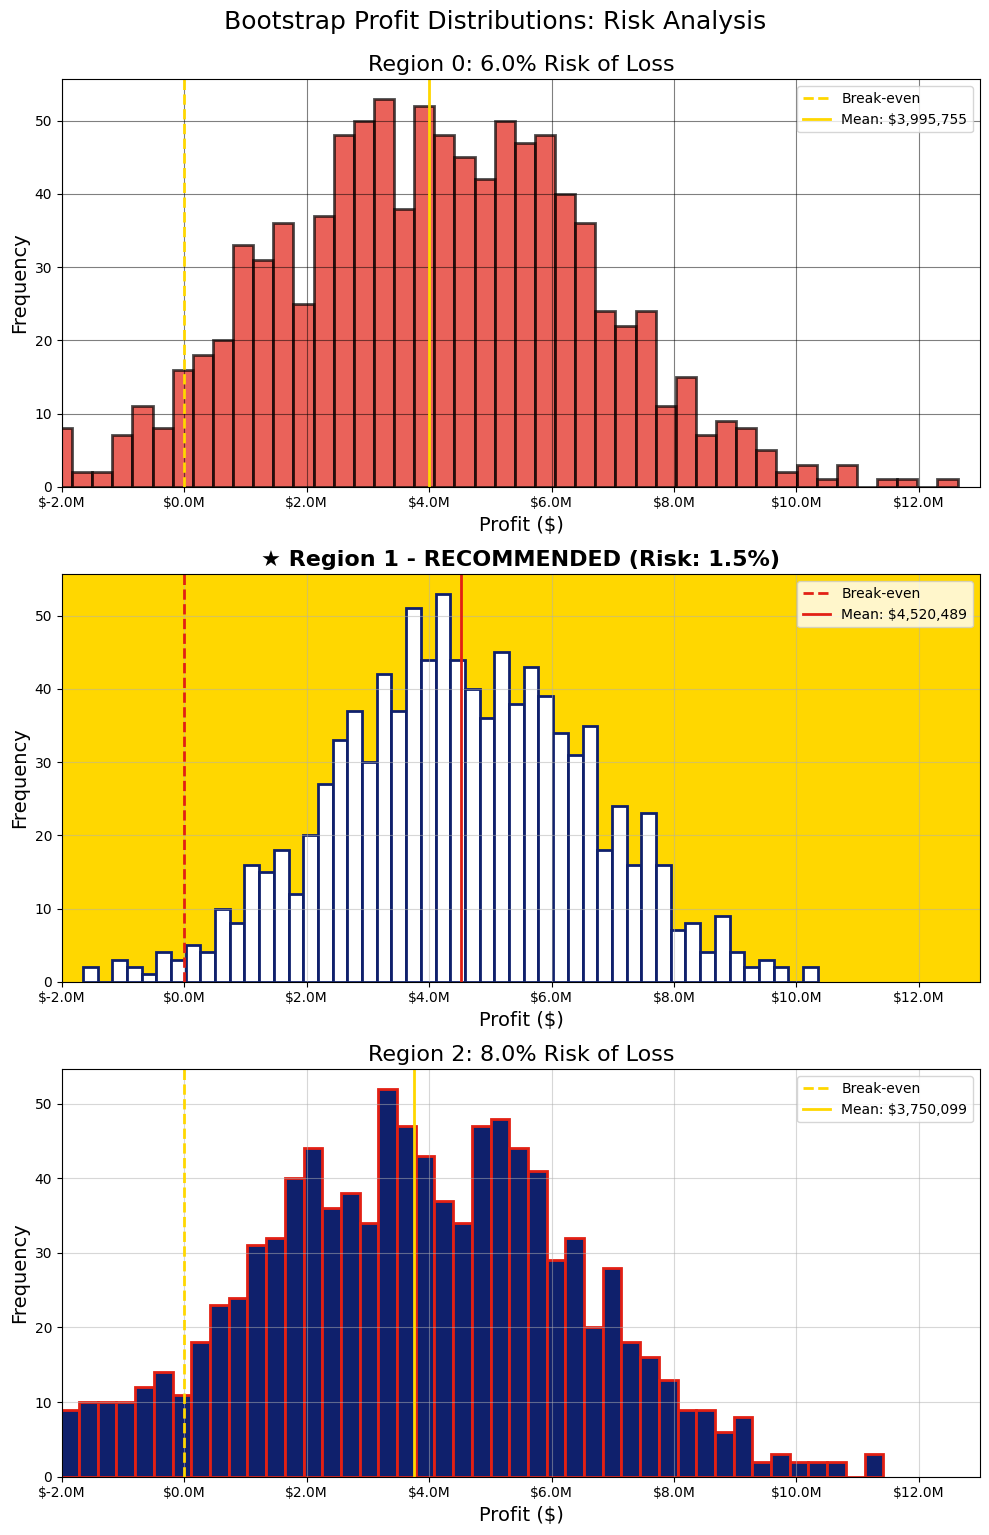

In [30]:
fig, axes = plt.subplots(3, 1, figsize=(10, 15))

axes[0].hist(profits0, bins=50, alpha=0.7, color='#e22014', edgecolor='black', linewidth=2)
axes[0].axvline(0, color='#FFD700', linestyle='--', linewidth=2, label='Break-even')
axes[0].axvline(profits0.mean(), color='#FFD700', linewidth=2, label=f'Mean: ${profits0.mean():,.0f}')
axes[0].set_title('Region 0: 6.0% Risk of Loss', fontsize=16)
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))
axes[0].set_xlim(-2e6, 13e6)
axes[0].set_xlabel('Profit ($)', fontsize=14)
axes[0].set_ylabel('Frequency', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.5, color='black')


axes[1].hist(profits1, bins=50, alpha=1, color='white', edgecolor='#0f206c', linewidth=2)
axes[1].axvline(0, color='#e22014', linestyle='--', linewidth=2, label='Break-even')
axes[1].axvline(profits1.mean(), color='#e22014', linewidth=2, label=f'Mean: ${profits1.mean():,.0f}')
axes[1].set_facecolor('#FFD700')
axes[1].set_title('★ Region 1 - RECOMMENDED (Risk: 1.5%)', fontsize=16, fontweight='bold')
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))
axes[1].set_xlim(-2e6, 13e6)
axes[1].set_xlabel('Profit ($)', fontsize=14)
axes[1].set_ylabel('Frequency', fontsize=14)
axes[1].legend()
axes[1].grid(True, alpha=0.5)


axes[2].hist(profits2, bins=50, color='#0f206c', edgecolor='#e22014', linewidth=2)
axes[2].axvline(0, color='#FFD700', linestyle='--', linewidth=2, label='Break-even')
axes[2].axvline(profits2.mean(), color='#FFD700', linewidth=2, label=f'Mean: ${profits2.mean():,.0f}')
axes[2].set_title('Region 2: 8.0% Risk of Loss', fontsize=16)
axes[2].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))
axes[2].set_xlim(-2e6, 13e6)
axes[2].set_xlabel('Profit ($)', fontsize=14)
axes[2].set_ylabel('Frequency', fontsize=14)
axes[2].legend()
axes[2].grid(True, alpha=0.5)

plt.tight_layout()
plt.suptitle('Bootstrap Profit Distributions: Risk Analysis', fontsize=18, y=1.02)
plt.show()

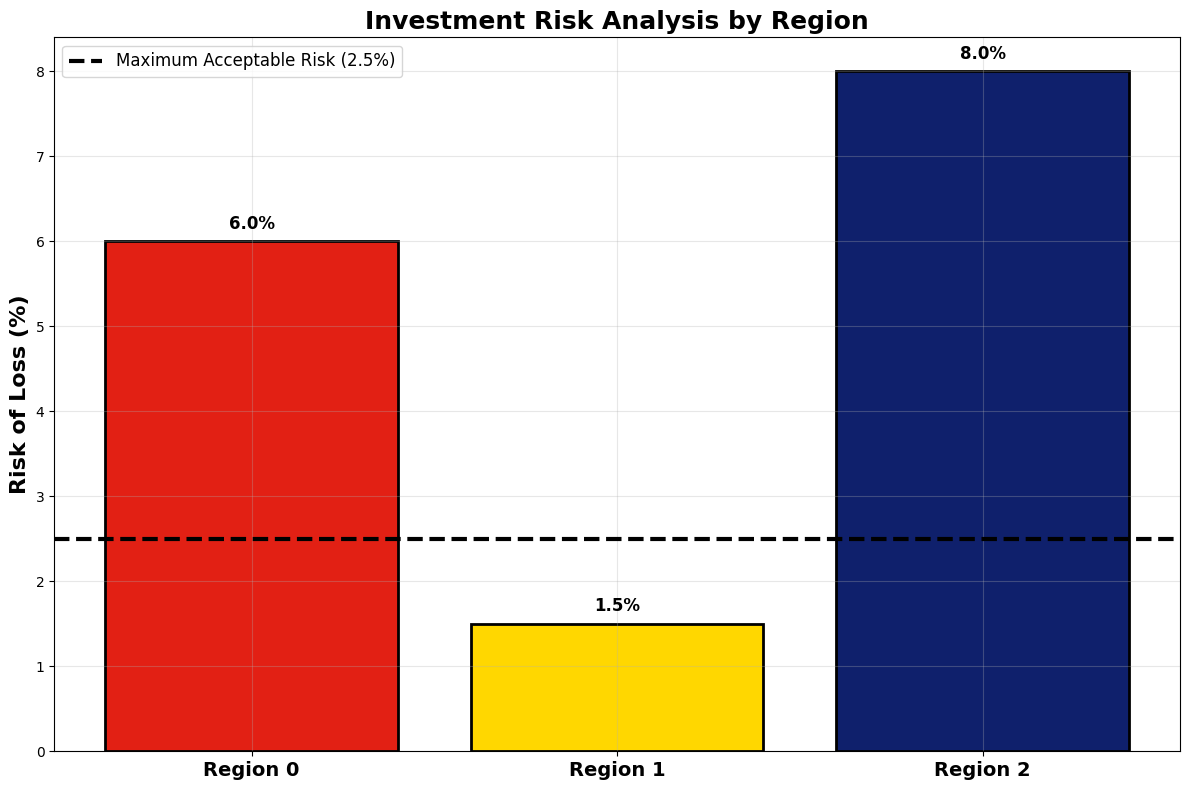

In [31]:
regions = ['Region 0', 'Region 1', 'Region 2']
risk_percentages = [6.0, 1.5, 8.0]
colors = ['#e22014', '#FFD700', '#0f206c']

plt.figure(figsize=(12, 8))
bars = plt.bar(regions, risk_percentages, color=colors, alpha=1, 
               edgecolor='black', linewidth=2)

plt.axhline(2.5, color='black', linestyle='--', linewidth=3, 
            label='Maximum Acceptable Risk (2.5%)')

plt.xticks(fontsize=14, fontweight='bold')
plt.ylabel('Risk of Loss (%)', fontsize=16, fontweight='bold')
plt.title('Investment Risk Analysis by Region', fontsize=18, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

for bar, risk in zip(bars, risk_percentages):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{risk}%', ha='center', va='bottom', fontweight='bold', fontsize=12)
    

plt.tight_layout()
plt.show()

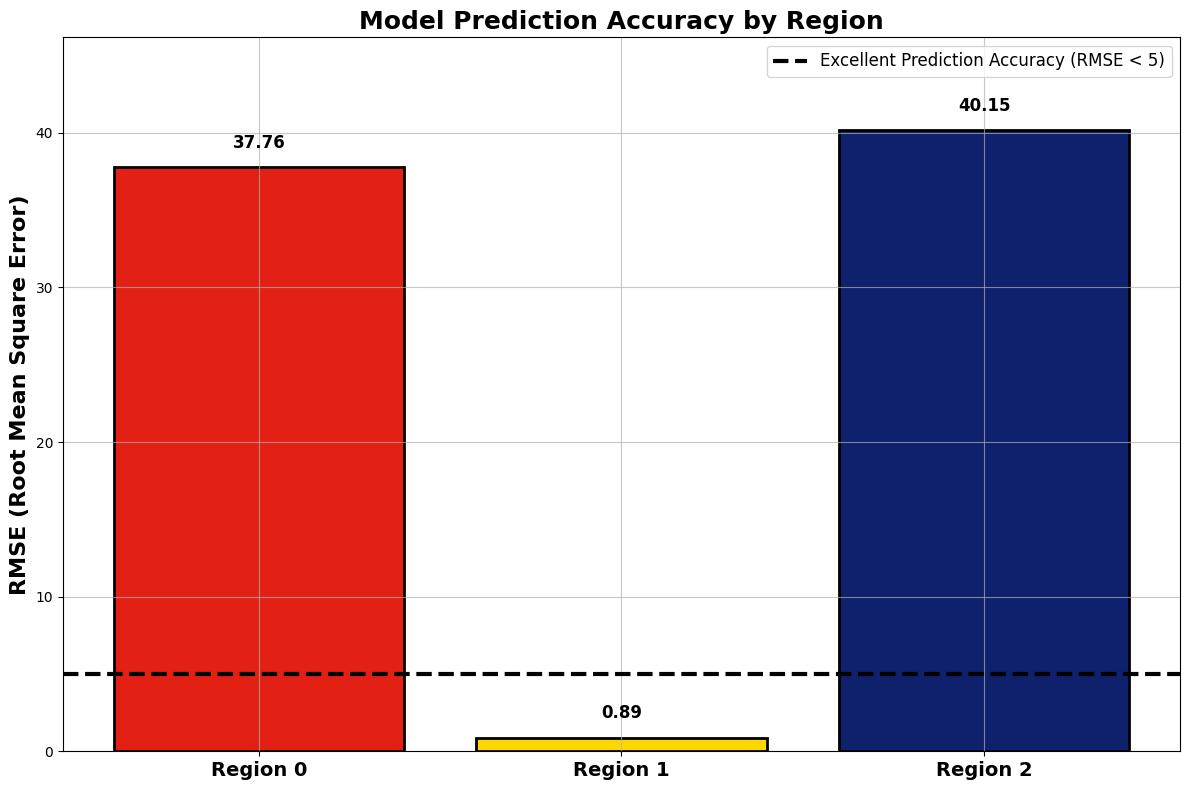

In [32]:
regions = ['Region 0', 'Region 1', 'Region 2']
rmse_values = [37.76, 0.89, 40.15]
colors = ['#e22014', '#FFD700', '#0f206c']

plt.figure(figsize=(12, 8))
bars = plt.bar(regions, rmse_values, color=colors, alpha=1,
               edgecolor='black', linewidth=2)

plt.axhline(5, color='black', linestyle='--', linewidth=3,
            label='Excellent Prediction Accuracy (RMSE < 5)')

plt.xticks(fontsize=14, fontweight='bold')
plt.ylabel('RMSE (Root Mean Square Error)', fontsize=16, fontweight='bold')
plt.title('Model Prediction Accuracy by Region', fontsize=18, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.7)

for bar, rmse in zip(bars, rmse_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{rmse:.2f}', ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.ylim(0, max(rmse_values) * 1.15)
plt.tight_layout()
plt.show()


### Final Recommendation

Based on the bootstrap analysis, **Region 1 is the only region that meets OilyGiant’s required risk threshold of 2.5%**. While Regions 0 and 2 show positive average profits, both carry significantly higher risks (6% and 8%, respectively), making them unsuitable for a \\$100 million investment.

Region 1, however, demonstrates:

- **Average profit:** \\$4.52 million  
- **95% confidence interval:** \\$616,845 to \\$8,453,402  
- **Risk of loss:** **1.5%** (below the 2.5% threshold)  
- **Extremely low RMSE (0.89)**, indicating highly reliable predictions  

Although Region 1 has lower average reserves compared to Regions 0 and 2, its **predictability and low risk** make it the safest and most financially responsible choice. In high‑stakes investment scenarios, reliability outweighs higher—but uncertain—returns.

### Recommendation

**OilyGiant should proceed with development in Region 1.**  
It is the only region that satisfies both profitability and risk requirements and offers the most stable foundation for a \\$100 million investment.

### Next Steps

To further strengthen decision‑making and reduce uncertainty, the company may also consider:

- Collecting additional geological features beyond f0–f2  
- Increasing the number of surveyed well locations  
- Incorporating historical production data from nearby wells  
- Enhancing geological mapping resolution  

These improvements could refine future predictions and support long‑term strategic planning.

